In [4]:
# ============================================================
# HEBREW FONT SETUP  - must run before any plotting
# ============================================================
import os
from shap_rtl.rtl_utils import (set_current_language, set_rtl_font_path,
                                _find_rtl_font, render_rtl_label, is_rtl_text)

package_dir = r"C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package"
if package_dir not in sys.path:
    sys.path.insert(0, package_dir)

set_current_language("Hebrew")

font_path, font_name = _find_rtl_font("Hebrew")

if font_path:
    print(f"Hebrew font found: {font_name}")
    set_rtl_font_path(font_path)
else:
    print("Hebrew font not found, trying fallbacks...")
    for path in [
        os.path.join(package_dir, "fonts", "NotoSansHebrew-Regular.ttf"),
        os.path.join(os.getcwd(), "fonts", "NotoSansHebrew-Regular.ttf"),
        r"C:\Windows\Fonts\arial.ttf",
    ]:
        if os.path.exists(path):
            print(f"Using fallback: {path}")
            set_rtl_font_path(path)
            font_path = path
            break

# Verify before going further - catching it here beats debugging plots later
test_text = "שלום עולם"
print("RTL detected:", is_rtl_text(test_text))
if font_path:
    img = render_rtl_label(test_text, font_path, font_size_pt=20, dpi=150)
    print("Render test image size:", img.size)
    if img.size[0] <= 1:
        print("WARNING: render produced nothing - the font is not working.")
else:
    print("ERROR: no Hebrew font set. Plots will show boxes.")

[DEBUG] Current language set to: Hebrew
Hebrew font found: NotoSansHebrew-Regular.ttf
[INFO] Font registered with matplotlib: Noto Sans Hebrew
RTL detected: True
Render test image size: (189, 40)


HEBREW DATASET
shape: (1000, 8)

'Label' values: <StringArray>
[          'Hate',            'NOT',       'violence',           'hate',
       'Violence',              nan,  'Hate, Abusive',        'Abusive',
 'Hate, violence',   'Hate,abusive']
Length: 10, dtype: str
'label' values: [1 0]

Class distribution:
  Normal: 863 (86.3%)
  Offensive: 137 (13.7%)

Train: 800   Test: 200
TF-IDF train shape: (800, 1000)
Model trained.
c:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\shap_rtl\fonts\NotoNastaliqUrdu-Regular.ttf
[INFO] Loaded Hebrew font: NotoSansHebrew-Regular.ttf
[INFO] Font path: c:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\fonts\NotoSansHebrew-Regular.ttf
[INFO] Font display name: Noto Sans Hebrew

🔤 RTL SHAP Explainer Initialized
   Language: Hebrew
   API Type: groq
   Font: NotoSansHebrew-Regular.ttf
   Translations: Enabled → English
   Max features to translate: 50

RTL explainer ready.

CONFUSION

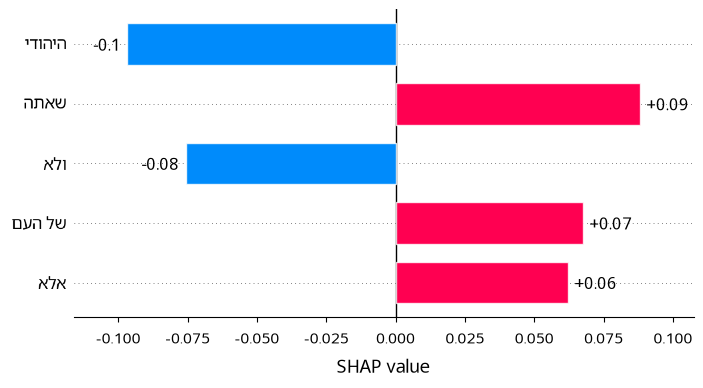


[Hebrew Explanation Mode]
------------------------------------------------------------------------------------------------------------------------
                                                                                                      PREDICTION: Normal
------------------------------------------------------------------------------------------------------------------------
                                                                               
Analysis of Top 1 SHAP Features (Hebrew)
--------------------------------------------------

Feature: היהודי | Value: -0.0967
----------------------------------------
המילה “היהודי” היא צורת ההגדרה של אדם שמזוהה עם היהדות, משמשת בדרך כלל לתיאור זהות דתית או אתנית; במקטע שסופק, המילה מופיעה ללא הקשר נוסף ולכן משמשת פשוט כהזכרת של קבוצה אתנית, מה שעלול להיתפס כמרכיב רגיש או מעורר תגובה במערכת סיווג טקסטים, ולכן המודל מעניק משקל שלילי לתוצאה “Normal” מכיוון שהזכרת קבוצה כזו נחשבת לפוטנציאל של תוכן שאינו רגיל או נייטרלי.
-------

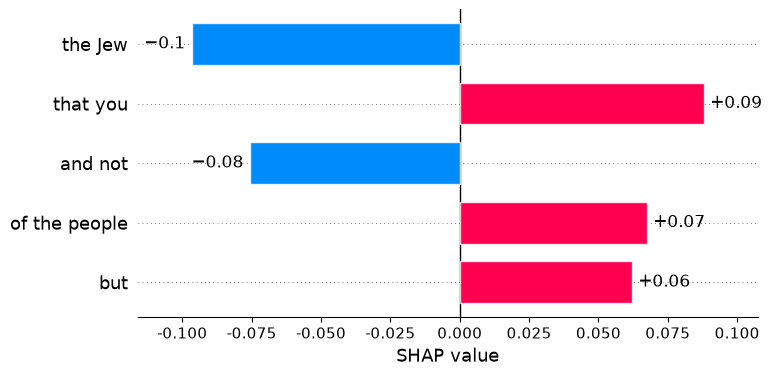


                              ENGLISH EXPLANATIONS                              

Original Hebrew Sample:
  הנה בבקשה כוונתך שאתה ״לא ציוני״ אך לא מתנגד לציונות יעני ״לא תומך בזכותו של העם היהודי להגדרה עצמית אבל אם הם מתעקשים סבבה״ הציונות אינה מונח דתי ולא בטיח אלא תפיסה מדינית נטו מדינת העם היהודי אי אפשר גם להתנגד לתפיסה זו או סתם לא להחזיק בה ולתמוך בישראל

Translated English Sample:
  Here, please, your point is that you are non‑Zionist but not opposed to Zionism—i.e., I don’t support the Jewish people’s right to self‑determination, but if they insist, fine. Zionism is not a religious term nor a belief, but a purely political notion: the state of the Jewish people. One cannot also oppose this notion or simply not hold it and still support Israel.
--------------------------------------------------------------------------------

[English Explanation Mode]
--------------------------------------------------------------------------------
                               PREDICTION: Nor

In [5]:
# ============================================================
# HEBREW SHAP RTL ANALYSIS - FULL PIPELINE
# ============================================================
import sys, warnings
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             f1_score, accuracy_score)
warnings.filterwarnings("ignore")

from shap_rtl.plots import bar, force, waterfall, beeswarm, heatmap, scatter, decision_plot
from shap_rtl import RTLSHAPExplainer

# ============================================================
# DATASET
# ============================================================
DATA_PATH = r"C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Datasets\HEBREW.csv"
df = pd.read_csv(DATA_PATH)

TEXT_COLUMN  = "clean_text"
LABEL_COLUMN = "label"          # switch to "Label" if the counts below look wrong

print("=" * 70)
print("HEBREW DATASET")
print("=" * 70)
print("shape:", df.shape)

# You have two label columns - check they agree before trusting either
if "Label" in df.columns and "label" in df.columns:
    print("\n'Label' values:", df["Label"].unique()[:10])
    print("'label' values:", df["label"].unique()[:10])

df[TEXT_COLUMN] = df[TEXT_COLUMN].fillna("").astype(str)
df = df[df[TEXT_COLUMN].str.strip() != ""].copy()

# ============================================================
# LABEL MAPPING
# ============================================================
def map_label(x):
    if isinstance(x, str):
        x = x.strip().lower()
        if x in ["offensive", "abusive", "hate", "hateful", "yes", "true", "1"]:
            return 1
        if x in ["normal", "none", "not offensive", "non-offensive", "no", "false", "0"]:
            return 0
    try:
        return 1 if int(float(x)) > 0 else 0
    except Exception:
        return np.nan

df["y"] = df[LABEL_COLUMN].apply(map_label)
df = df.dropna(subset=["y"]).copy()
df["y"] = df["y"].astype(int)

class_names = {0: "Normal", 1: "Offensive"}

print("\nClass distribution:")
for cid, name in class_names.items():
    n = (df["y"] == cid).sum()
    print(f"  {name}: {n} ({n/len(df)*100:.1f}%)")

# ============================================================
# TRAIN / TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    df[TEXT_COLUMN], df["y"],
    test_size=0.2, random_state=42, stratify=df["y"])

print(f"\nTrain: {len(X_train)}   Test: {len(X_test)}")

# ============================================================
# TF-IDF
# ============================================================
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2), analyzer="word",
    max_features=1000, min_df=2, max_df=0.95)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)
feature_names = np.array(vectorizer.get_feature_names_out())

print("TF-IDF train shape:", X_train_vec.shape)

# ============================================================
# MODEL
# ============================================================
model = LogisticRegression(
    max_iter=1000, class_weight="balanced",
    random_state=42, solver="liblinear", C=1.0)
model.fit(X_train_vec, y_train)
print("Model trained.")

# ============================================================
# SHAP BACKGROUND + EXPLAINERS
# ============================================================
masker = shap.maskers.Independent(data=X_train_vec[:100], max_samples=100)
shap_explainer = shap.LinearExplainer(model, masker=masker)

explainer_rtl = RTLSHAPExplainer(
    language="Hebrew",
    model=model,
    vectorizer=vectorizer,
    api_type="groq")

print("RTL explainer ready.")

# ============================================================
# CLASSIFICATION PERFORMANCE
# ============================================================
y_train_pred = model.predict(X_train_vec)
y_test_pred  = model.predict(X_test_vec)
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred, labels=[0, 1]).ravel()

print("\n" + "=" * 70)
print("CONFUSION MATRIX (test set)")
print("=" * 70)
print("                    Pred Normal    Pred Offensive")
print(f"  Actual Normal        TN = {tn:<10} FP = {fp}")
print(f"  Actual Offensive     FN = {fn:<10} TP = {tp}")

print("\n" + "=" * 70)
print("METRICS")
print("=" * 70)
print(f"  Train accuracy : {accuracy_score(y_train, y_train_pred):.4f}")
print(f"  Test accuracy  : {accuracy_score(y_test,  y_test_pred):.4f}")
print(f"  Macro F1       : {f1_score(y_test, y_test_pred, average='macro'):.4f}")
print(f"  Weighted F1    : {f1_score(y_test, y_test_pred, average='weighted'):.4f}")
print(f"  F1 (Normal)    : {f1_score(y_test, y_test_pred, pos_label=0):.4f}")
print(f"  F1 (Offensive) : {f1_score(y_test, y_test_pred, pos_label=1):.4f}")

print("\n" + classification_report(y_test, y_test_pred,
        target_names=["Normal", "Offensive"], digits=4))

majority = y_test.value_counts(normalize=True).max()
print(f"Majority-class baseline : {majority:.4f}")
print(f"Model beats baseline by : {accuracy_score(y_test, y_test_pred) - majority:+.4f}")
print(f"Offensive instances in test set: {int(y_test.sum())}")

# ============================================================
# ANALYZE ONE SAMPLE WITH RTL PLOTS
# ============================================================
def analyze_sample(sample_text, plot_type="bar", max_features=5):
    vec = vectorizer.transform([sample_text])
    dense = vec.toarray()[0]
    present_idx = np.where(dense > 0)[0]

    if len(present_idx) == 0:
        print("No TF-IDF features in this sample.")
        return

    probs = model.predict_proba(vec)[0]
    pred_class = int(np.argmax(probs))
    prediction_label = class_names[pred_class]

    print("\n" + "=" * 70)
    print("HEBREW SHAP ANALYSIS")
    print("=" * 70)
    print("Sample:", sample_text)
    print("Prediction:", prediction_label)
    for cid, p in enumerate(probs):
        print(f"  {class_names[cid]}: {p:.4f}")

    res = shap_explainer(vec)
    values = np.asarray(res.values).flatten()
    base_value = np.asarray(res.base_values).flatten()[0]

    present_shap = values[present_idx]
    order = np.argsort(np.abs(present_shap))[::-1][:max_features]
    top_idx = present_idx[order]

    print(f"\nTop {len(top_idx)} features:")
    for rank, i in enumerate(top_idx, 1):
        print(f"  {rank}. {feature_names[i]}: {values[i]:+.6f}")

    explanation = shap.Explanation(
        values=values[top_idx],
        base_values=base_value,
        data=dense[top_idx],
        feature_names=list(feature_names[top_idx]))

    plot_functions = {"bar": bar, "waterfall": waterfall, "force": force,
                      "beeswarm": beeswarm, "heatmap": heatmap,
                      "scatter": scatter, "decision_plot": decision_plot}

    explainer_rtl.run_full_analysis(
        shap_values=explanation,
        prediction_label=prediction_label,
        plot_fn=plot_functions[plot_type],
        sample_text=sample_text,
        max_features=max_features,
        allow_positive_negative_split=True)
    plt.show()


# Pick a real test sample with enough features rather than hardcoding one
counts = np.asarray((X_test_vec > 0).sum(axis=1)).ravel()
sample_text = X_test.iloc[int(np.argmax(counts))]

analyze_sample(sample_text, plot_type="bar", max_features=5)


In [7]:
# ============================================================
# CLASSIFICATION PERFORMANCE (HEBREW)
# ============================================================
y_train_pred = model.predict(X_train_vec)
y_test_pred  = model.predict(X_test_vec)

tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred, labels=[0, 1]).ravel()

print("=" * 60)
print("CONFUSION MATRIX (test set)")
print("=" * 60)
print("                  Pred Normal    Pred Offensive")
print(f"  Actual Normal      TN = {tn:<10} FP = {fp}")
print(f"  Actual Offensive   FN = {fn:<10} TP = {tp}")

print("\n" + "=" * 60)
print("METRICS")
print("=" * 60)
print(f"  Train accuracy : {accuracy_score(y_train, y_train_pred):.4f}")
print(f"  Test accuracy  : {accuracy_score(y_test,  y_test_pred):.4f}")
print(f"  Macro F1       : {f1_score(y_test, y_test_pred, average='macro'):.4f}")
print(f"  F1 (Offensive) : {f1_score(y_test, y_test_pred, pos_label=1):.4f}")

print("\n" + classification_report(y_test, y_test_pred,
        target_names=["Normal", "Offensive"], digits=4))

majority = y_test.value_counts(normalize=True).max()
print(f"Majority-class baseline: {majority:.4f}")
print(f"Model beats baseline by: {accuracy_score(y_test, y_test_pred) - majority:+.4f}")
print(f"Offensive instances in test set: {int(y_test.sum())}")

CONFUSION MATRIX (test set)
                  Pred Normal    Pred Offensive
  Actual Normal      TN = 134        FP = 39
  Actual Offensive   FN = 13         TP = 14

METRICS
  Train accuracy : 0.9163
  Test accuracy  : 0.7400
  Macro F1       : 0.5938
  F1 (Offensive) : 0.3500

              precision    recall  f1-score   support

      Normal     0.9116    0.7746    0.8375       173
   Offensive     0.2642    0.5185    0.3500        27

    accuracy                         0.7400       200
   macro avg     0.5879    0.6465    0.5938       200
weighted avg     0.8242    0.7400    0.7717       200

Majority-class baseline: 0.8650
Model beats baseline by: -0.1250
Offensive instances in test set: 27


In [6]:

# ============================================================
# CELL 6: EXPORT FEATURE WORDS FOR THE OCR TEST
# ============================================================
LANG = "heb"
OUT = Path(r"C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\ocr_experiment\data")
OUT.mkdir(parents=True, exist_ok=True)

X = X_test_vec[:300]
keep = np.asarray(X.sum(axis=1)).ravel() > 0
X = X[keep]
print(f"\nUsing {X.shape[0]} test samples, {X.shape[1]} features")

sv = np.asarray(shap_explainer(X).values)
if sv.ndim == 3:
    sv = sv[:, :, 1]

np.save(OUT / f"{LANG}_shap_values.npy", sv)
np.save(OUT / f"{LANG}_feature_names.npy", np.array(feature_names, dtype=object))

print("saved shape:", sv.shape)
print("saved to:", OUT.resolve())


Using 200 test samples, 1000 features
saved shape: (200, 1000)
saved to: C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\ocr_experiment\data
